In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/salikhussaini49/prediction-of-sepsis/SHA256SUMS.txt
/kaggle/input/datasets/salikhussaini49/prediction-of-sepsis/utility_sepsis_diagram.svg
/kaggle/input/datasets/salikhussaini49/prediction-of-sepsis/physionet_challenge_2019_ccm_manuscript.pdf
/kaggle/input/datasets/salikhussaini49/prediction-of-sepsis/utility_nonsepsis_diagram.svg
/kaggle/input/datasets/salikhussaini49/prediction-of-sepsis/LICENSE.txt
/kaggle/input/datasets/salikhussaini49/prediction-of-sepsis/Dataset.csv


In [32]:
import warnings
warnings.filterwarnings("ignore")
 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
import optuna
 
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
 
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score,
    train_test_split
)
 
from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, confusion_matrix, classification_report, auc,
    RocCurveDisplay, ConfusionMatrixDisplay, log_loss
)
 
from sklearn.calibration import calibration_curve, CalibrationDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.inspection import PartialDependenceDisplay
 
from xgboost import XGBClassifier
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l1_l2

In [33]:
CSV_PATH = '/kaggle/input/datasets/salikhussaini49/prediction-of-sepsis/Dataset.csv' 
df = pd.read_csv(CSV_PATH)
print(f"dataset loaded: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

dataset loaded: (1552210, 44)
Columns: ['Unnamed: 0', 'Hour', 'HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'EtCO2', 'BaseExcess', 'HCO3', 'FiO2', 'pH', 'PaCO2', 'SaO2', 'AST', 'BUN', 'Alkalinephos', 'Calcium', 'Chloride', 'Creatinine', 'Bilirubin_direct', 'Glucose', 'Lactate', 'Magnesium', 'Phosphate', 'Potassium', 'Bilirubin_total', 'TroponinI', 'Hct', 'Hgb', 'PTT', 'WBC', 'Fibrinogen', 'Platelets', 'Age', 'Gender', 'Unit1', 'Unit2', 'HospAdmTime', 'ICULOS', 'SepsisLabel', 'Patient_ID']


# EDA

 Target Distribution:
SepsisLabel
0    1524294
1      27916
Name: count, dtype: int64

  Imbalance Ratio: 54.60


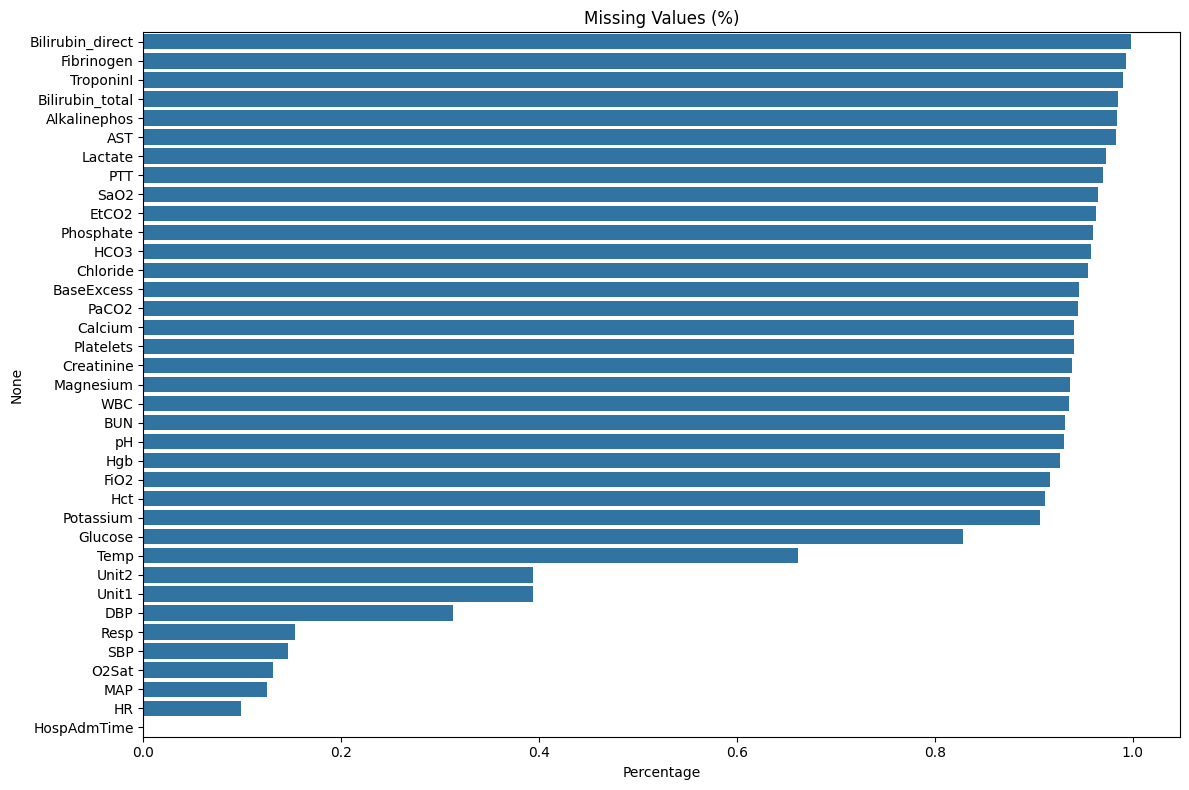


 Numeric Features Summary:


,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,1552210.0,25.492745,28.882557,0.00,9.00,19.000,33.00,335.00
Hour,1552210.0,25.492745,28.882557,0.00,9.00,19.000,33.00,335.00
HR,1398811.0,84.581443,17.325242,20.00,72.00,83.500,95.50,280.00
O2Sat,1349474.0,97.193955,2.936924,20.00,96.00,98.000,99.50,100.00
Temp,525226.0,36.977228,0.770014,20.90,36.50,37.000,37.50,50.00
SBP,1325945.0,123.750465,23.231556,20.00,107.00,121.000,138.00,300.00
MAP,1358940.0,82.400100,16.341750,20.00,71.00,80.000,92.00,300.00
DBP,1065656.0,63.830556,13.956010,20.00,54.00,62.000,72.00,300.00
Resp,1313875.0,18.726498,5.098194,1.00,15.00,18.000,21.50,100.00
EtCO2,57636.0,32.957657,7.951662,10.00,28.00,33.000,38.00,100.00


In [34]:
print(" Target Distribution:")
print(df['SepsisLabel'].value_counts())
print(f"\n  Imbalance Ratio: {(df['SepsisLabel']==0).sum()/(df['SepsisLabel']==1).sum():.2f}")

# Missing values heatmap
plt.figure(figsize=(12, 8))
missing = df.isnull().mean().sort_values(ascending=False)
missing = missing[missing > 0]
sns.barplot(x=missing.values, y=missing.index)
plt.title('Missing Values (%)')
plt.xlabel('Percentage')
plt.tight_layout()
plt.show()

# Numeric summary
print("\n Numeric Features Summary:")
df.select_dtypes(include=[np.number]).describe().T

In [35]:
from scipy import stats

# Compare Survivors vs Sepsis Patients

target = 'SepsisLabel'
compare_cols = ['HR', 'Temp', 'MAP', 'Resp', 'Age', 'BUN', 'Creatinine', 'WBC', 'O2Sat', 'SBP']
available_cols = [c for c in compare_cols if c in df.columns]

results = []
for col in available_cols:
    if df[col].notna().sum() > 100:
        surv = df[df[target]==0][col].dropna()
        seps = df[df[target]==1][col].dropna()
        if len(surv) > 0 and len(seps) > 0:
            stat, p = stats.mannwhitneyu(surv, seps, alternative='two-sided')
            results.append({
                'Feature': col,
                'Survivor_Median': surv.median(),
                'Sepsis_Median': seps.median(),
                'P_value': p,
                'Significant': p < 0.05
            })

results_df = pd.DataFrame(results).sort_values('P_value')
print(results_df.to_string(index=False))

   Feature  Survivor_Median  Sepsis_Median       P_value  Significant
        HR            83.00           90.0  0.000000e+00         True
      Resp            18.00           20.0  0.000000e+00         True
      Temp            37.00           37.3 4.614455e-232         True
       MAP            80.00           78.0 4.621038e-129         True
       BUN            17.00           24.0  7.127604e-80         True
       SBP           121.00          118.0  1.753073e-69         True
Creatinine             0.93            1.2  2.950937e-45         True
       WBC            10.30           11.8  1.713801e-34         True
     O2Sat            98.00           98.0  1.263357e-04         True
       Age            64.00           64.0  6.771062e-01        False


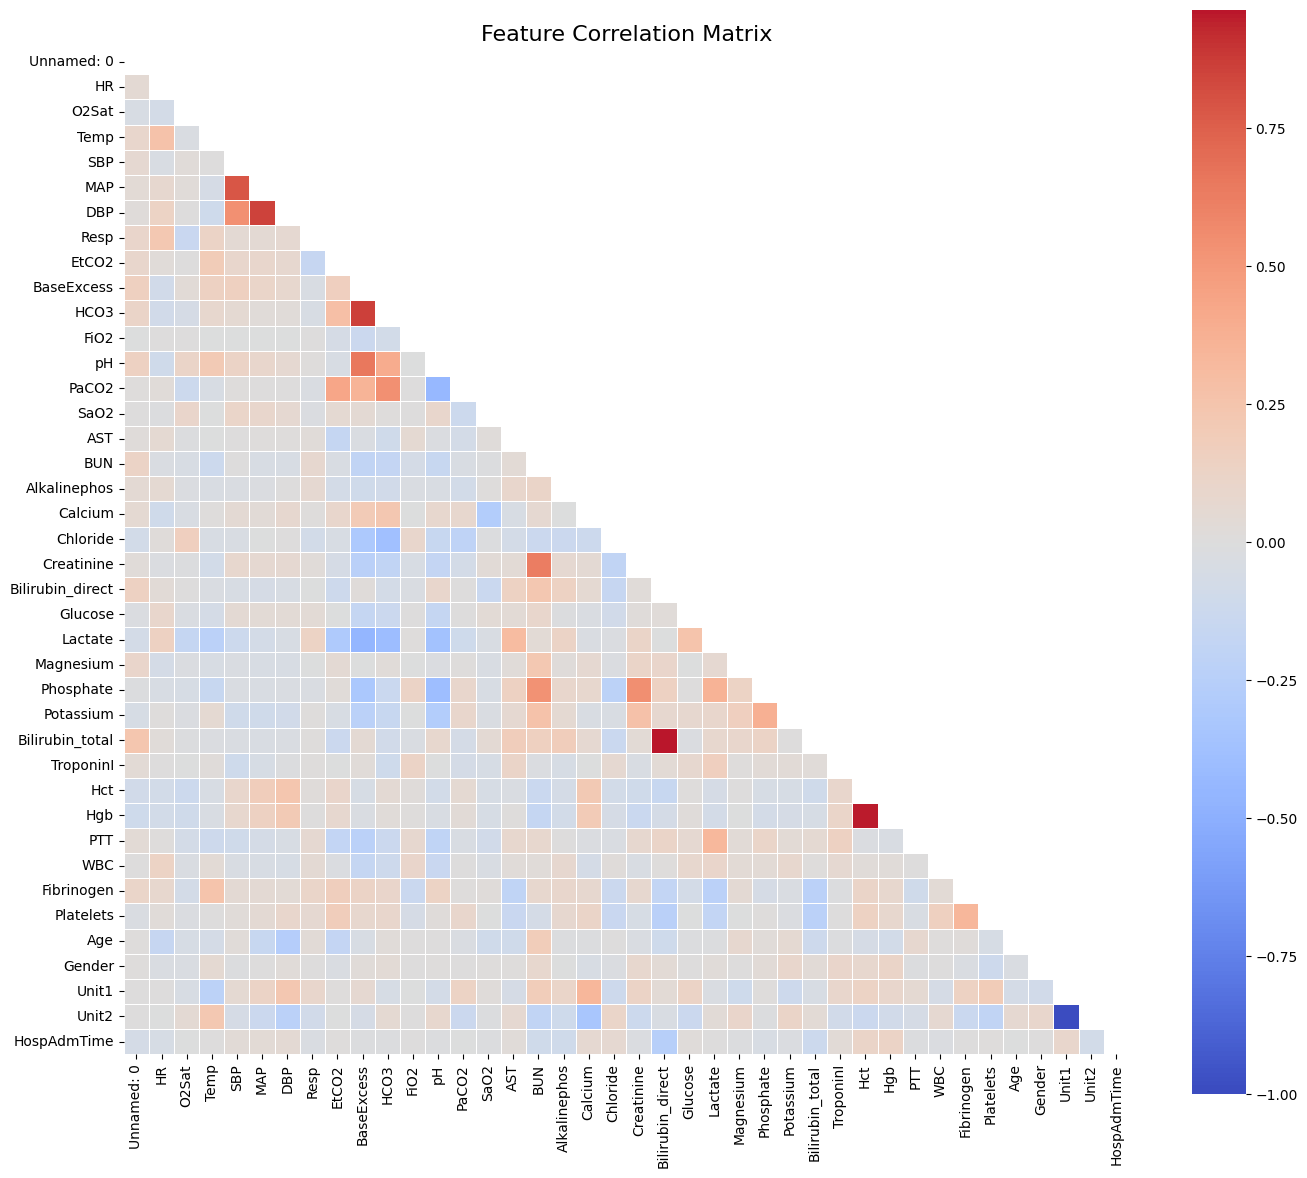

In [36]:
# Correlation Heatmap

# Select numeric columns only
numeric_df = df.select_dtypes(include=[np.number]).drop(
    columns=['SepsisLabel', 'Patient_ID', 'Hour', 'ICULOS'], 
    errors='ignore'
)

if numeric_df.shape[1] > 2:
    plt.figure(figsize=(14, 12))
    corr = numeric_df.corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0, square=True, linewidths=0.5)
    plt.title('Feature Correlation Matrix', fontsize=16)
    plt.tight_layout()
    plt.show()
    
    # Top correlations with target
    if 'SepsisLabel' in corr.columns:
        target_corr = corr['SepsisLabel'].drop('SepsisLabel').abs().sort_values(ascending=False)
        print("\n Top 10 Features Correlated with SepsisLabel:")
        print(target_corr.head(10))

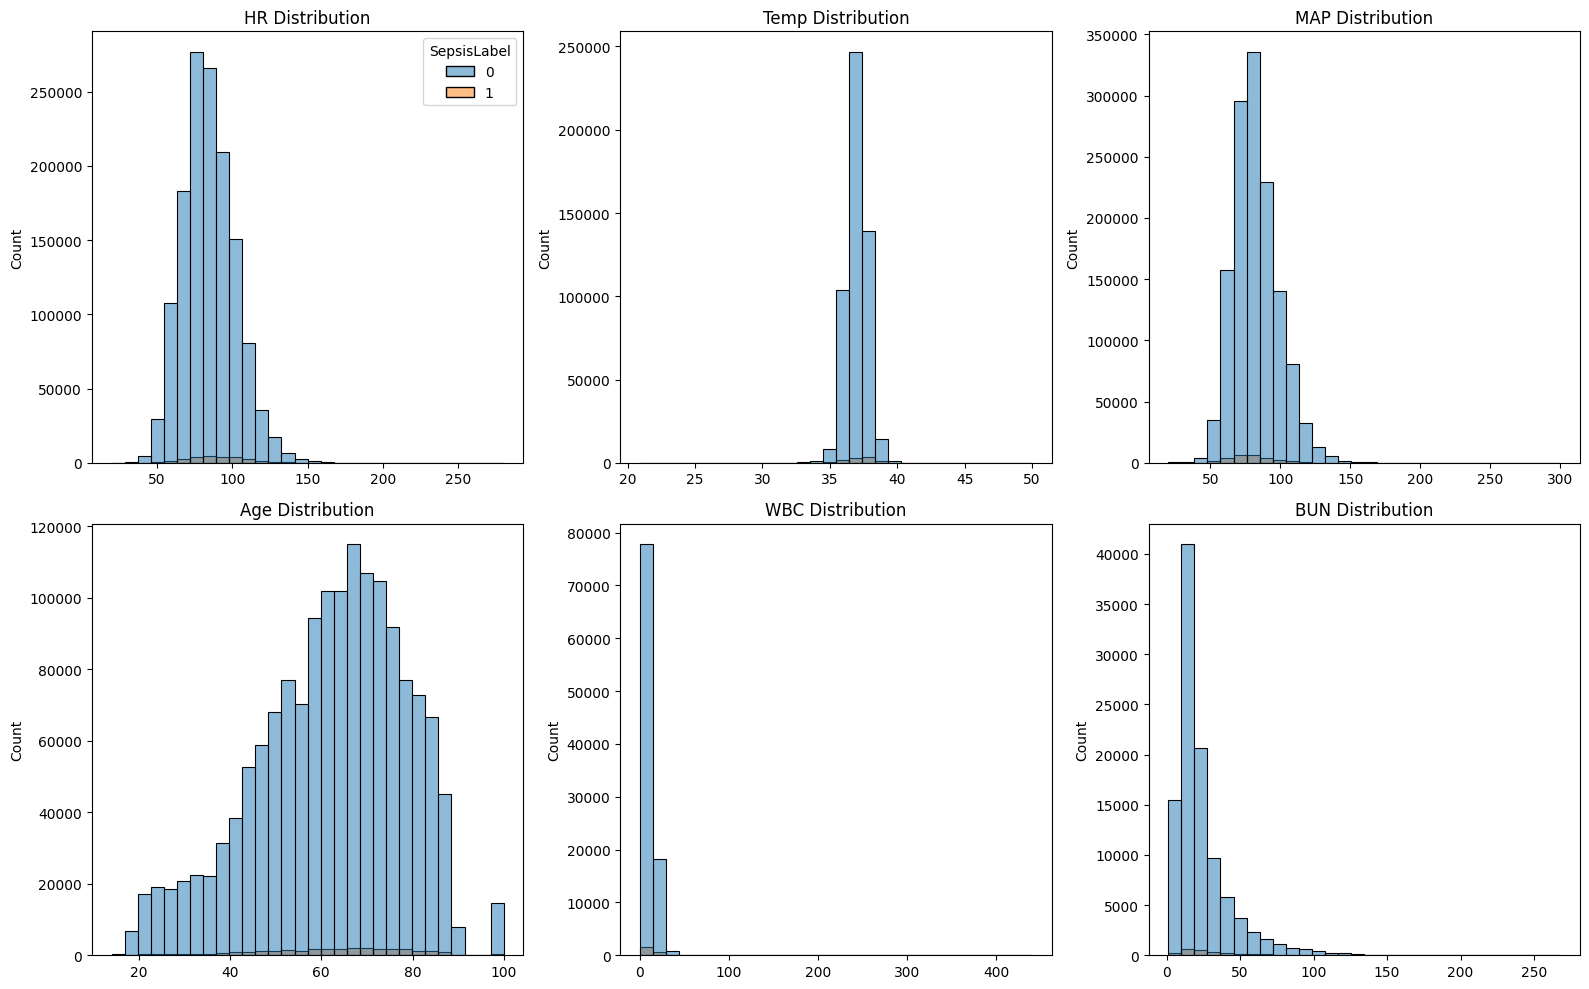

In [37]:
# Distribution Plots for Key Features

key_features = ['HR', 'Temp', 'MAP', 'Age', 'WBC', 'BUN', 'Creatinine']
available = [f for f in key_features if f in df.columns and df[f].notna().sum() > 100]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for idx, feat in enumerate(available[:6]):
    ax = axes[idx//3, idx%3]
    sns.histplot(data=df, x=feat, hue='SepsisLabel', bins=30, alpha=0.5, ax=ax, legend=idx==0)
    ax.set_title(f'{feat} Distribution')
    ax.set_xlabel('')
plt.tight_layout()
plt.show()

# Data Preprocessing

In [38]:
from sklearn.impute import SimpleImputer

In [39]:
TARGET = "SepsisLabel"

X = df.drop(columns=[TARGET])
y = df[TARGET]

In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [41]:
numeric_cols = X_train.select_dtypes(include=[np.number]).columns
categorical_cols = X_train.select_dtypes(exclude=[np.number]).columns

In [42]:
print(f" Numeric columns: {len(numeric_cols)} | Categorical columns: {len(categorical_cols)}")

 Numeric columns: 43 | Categorical columns: 0


In [43]:
if len(numeric_cols) > 0:
    num_imputer = SimpleImputer(strategy='median')
    X_train[numeric_cols] = num_imputer.fit_transform(X_train[numeric_cols])
    X_test[numeric_cols] = num_imputer.transform(X_test[numeric_cols])
    print(" Numeric imputation complete.")
else:
    print(" No numeric columns found.")

# Impute CATEGORICAL (Mode/Most Frequent)
if len(categorical_cols) > 0:
    cat_imputer = SimpleImputer(strategy='most_frequent')
    X_train[categorical_cols] = cat_imputer.fit_transform(X_train[categorical_cols])
    X_test[categorical_cols] = cat_imputer.transform(X_test[categorical_cols])
    print(" Categorical imputation complete.")
else:
    print(" No categorical columns found. Skipping categorical imputation.")

# Final Verification
assert X_train.isnull().sum().sum() == 0, "Train still has missing values!"
assert X_test.isnull().sum().sum() == 0, "Test still has missing values!"

print(f" Remaining missing values -> Train: {X_train.isnull().sum().sum()}, Test: {X_test.isnull().sum().sum()}")
print(f" Split & Imputation complete.")
print(f" Train shape: {X_train.shape} | Missing values: {X_train.isnull().sum().sum()}")
print(f" Test shape:  {X_test.shape}  | Missing values: {X_test.isnull().sum().sum()}")
print(f"  Class balance -> Train: {y_train.value_counts().to_dict()}, Test: {y_test.value_counts().to_dict()}")

 Numeric imputation complete.
 No categorical columns found. Skipping categorical imputation.
 Remaining missing values -> Train: 0, Test: 0
 Split & Imputation complete.
 Train shape: (1241768, 43) | Missing values: 0
 Test shape:  (310442, 43)  | Missing values: 0
  Class balance -> Train: {0: 1219435, 1: 22333}, Test: {0: 304859, 1: 5583}


In [44]:
# 3σ outlier capping (paper's approach)
for col in numeric_cols:

    mean = X_train[col].mean()
    std = X_train[col].std()

    lower = mean - 3 * std
    upper = mean + 3 * std

    X_train[col] = np.clip(X_train[col], lower, upper)
    X_test[col] = np.clip(X_test[col], lower, upper)

print(" Outliers capped using 3σ method")

 Outliers capped using 3σ method


# Feature selection

In [47]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
import time

print(" Running RFE + GBT Feature Selection.")
start = time.time()


n_sub = 50000
frac = n_sub / len(y_train)
X_sub, _, y_sub, _ = train_test_split(
    X_train, y_train, train_size=frac, stratify=y_train, random_state=42
)
print(f" Using stratified subsample: {X_sub.shape} for RFE...")


estimator = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    subsample=0.8, 
    random_state=42
)


n_select = min(25, X_train.shape[1])
rfe = RFE(
    estimator=estimator,
    n_features_to_select=n_select,
    step=5,
    verbose=1
)


rfe.fit(X_sub, y_sub)
selected_features = X_train.columns[rfe.support_].tolist()
X_train_sel = X_train[selected_features]
X_test_sel = X_test[selected_features]

print(f" RFE complete in {time.time()-start:.1f}s")
print(f" Top {n_select} Features Selected:")
for i, feat in enumerate(selected_features, 1):
    print(f"   {i}. {feat}")
print(f"\n Final shapes -> Train: {X_train_sel.shape}, Test: {X_test_sel.shape}")

 Running RFE + GBT Feature Selection (Paper Sec 2.2.1)...
 Using stratified subsample: (50000, 43) for RFE...
Fitting estimator with 43 features.
Fitting estimator with 38 features.
Fitting estimator with 33 features.
Fitting estimator with 28 features.
 RFE complete in 64.6s
 Top 25 Features Selected:
   1. Unnamed: 0
   2. Hour
   3. HR
   4. O2Sat
   5. Temp
   6. SBP
   7. MAP
   8. DBP
   9. Resp
   10. EtCO2
   11. BaseExcess
   12. FiO2
   13. pH
   14. PaCO2
   15. SaO2
   16. BUN
   17. Calcium
   18. Creatinine
   19. Lactate
   20. TroponinI
   21. PTT
   22. Age
   23. HospAdmTime
   24. ICULOS
   25. Patient_ID

 Final shapes -> Train: (1241768, 25), Test: (310442, 25)


# Feature selection 

In [48]:
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()


X_train_scaled = scaler.fit_transform(X_train_sel)
X_test_scaled = scaler.transform(X_test_sel)

 
X_train_scaled = pd.DataFrame(X_train_scaled, columns=selected_features)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=selected_features)

print(f" Scaling complete.")
print(f" Train shape: {X_train_scaled.shape} | Test shape: {X_test_scaled.shape}")
print(f" Feature stats -> Mean: {X_train_scaled.mean().round(2)}, Std: {X_train_scaled.std().round(2)}")

 Scaling complete.
 Train shape: (1241768, 25) | Test shape: (310442, 25)
 Feature stats -> Mean: Unnamed: 0     0.0
Hour           0.0
HR             0.0
O2Sat         -0.0
Temp          -0.0
SBP           -0.0
MAP           -0.0
DBP            0.0
Resp           0.0
EtCO2          0.0
BaseExcess    -0.0
FiO2          -0.0
pH             0.0
PaCO2         -0.0
SaO2          -0.0
BUN            0.0
Calcium        0.0
Creatinine    -0.0
Lactate        0.0
TroponinI     -0.0
PTT           -0.0
Age            0.0
HospAdmTime    0.0
ICULOS         0.0
Patient_ID    -0.0
dtype: float64, Std: Unnamed: 0     1.0
Hour           1.0
HR             1.0
O2Sat          1.0
Temp           1.0
SBP            1.0
MAP            1.0
DBP            1.0
Resp           1.0
EtCO2          1.0
BaseExcess     1.0
FiO2           1.0
pH             1.0
PaCO2          1.0
SaO2           1.0
BUN            1.0
Calcium        1.0
Creatinine     1.0
Lactate        1.0
TroponinI      1.0
PTT            1.0
Age    

In [50]:
import pandas as pd
from sklearn.utils import resample
import os
import pickle

print(" Applying Balanced Sampling ")


train_df = X_train_scaled.copy()
train_df['SepsisLabel'] = y_train.values if hasattr(y_train, 'values') else y_train


majority = train_df[train_df['SepsisLabel'] == 0]
minority = train_df[train_df['SepsisLabel'] == 1]

majority_bal = resample(
    majority,
    replace=False,  
    n_samples=len(minority),
    random_state=42
)


train_balanced = pd.concat([majority_bal, minority])
train_balanced = train_balanced.sample(frac=1, random_state=42).reset_index(drop=True)


X_train_bal = train_balanced.drop(columns=['SepsisLabel'])
y_train_bal = train_balanced['SepsisLabel']

print(f" Balanced training set created.")
print(f" Original Train: {X_train_scaled.shape} | Survivors: {(y_train==0).sum()}, Deaths: {(y_train==1).sum()}")
print(f" Balanced Train: {X_train_bal.shape} | Survivors: {(y_train_bal==0).sum()}, Deaths: {(y_train_bal==1).sum()}")
print(f" New Ratio: {(y_train_bal==0).sum()/(y_train_bal==1).sum():.2f}:1")
print(f" Test set remains untouched: {X_test_scaled.shape} (for unbiased evaluation)")


save_dir = "morsnx_paper_ready"
os.makedirs(save_dir, exist_ok=True)

final_data = {
    'X_train_bal': X_train_bal,
    'y_train_bal': y_train_bal,
    'X_test': X_test_scaled,
    'y_test': y_test,
    'scaler': scaler,
    'selected_features': selected_features
}

 Applying Balanced Sampling 
 Balanced training set created.
 Original Train: (1241768, 25) | Survivors: 1219435, Deaths: 22333
 Balanced Train: (44666, 25) | Survivors: 22333, Deaths: 22333
 New Ratio: 1.00:1
 Test set remains untouched: (310442, 25) (for unbiased evaluation)


In [51]:
import pickle
import os

# Create dedicated folder for split files
save_dir = "morsnx_data_splits"
os.makedirs(save_dir, exist_ok=True)

# 📦 Package TRAINING DATA (Balanced + Scaled)
train_data = {
    'X': X_train_bal,
    'y': y_train_bal,
    'features': selected_features,
    'scaler': scaler
}

# 📦 Package TEST DATA (Original distribution + Scaled)
test_data = {
    'X': X_test_scaled,
    'y': y_test,
    'features': selected_features,
    'scaler': scaler
}

# Save to separate files
with open(f"{save_dir}/train_data.pkl", "wb") as f:
    pickle.dump(train_data, f)
    
with open(f"{save_dir}/test_data.pkl", "wb") as f:
    pickle.dump(test_data, f)

print(f"✅ Successfully saved to: {save_dir}/")
print(f"📦 train_data.pkl → X: {X_train_bal.shape}, y: {y_train_bal.shape} (Balanced 1:1)")
print(f"📦 test_data.pkl  → X: {X_test_scaled.shape}, y: {y_test.shape} (Original imbalance preserved)")
print(f"🔑 Features saved: {len(selected_features)}")

✅ Successfully saved to: morsnx_data_splits/
📦 train_data.pkl → X: (44666, 25), y: (44666,) (Balanced 1:1)
📦 test_data.pkl  → X: (310442, 25), y: (310442,) (Original imbalance preserved)
🔑 Features saved: 25


In [52]:
import pickle
import os


print("=" * 60)
print("Dataset Information")
print("=" * 60)

train_rows = len(X_train_bal)
train_sepsis = int(y_train_bal.sum())
train_pct = (train_sepsis / train_rows) * 100

test_rows = len(X_test_scaled)
test_sepsis = int(y_test.sum())
test_pct = (test_sepsis / test_rows) * 100

n_features = len(selected_features)

print(f"Training set: {train_rows:,} rows | Sepsis={train_sepsis:,} ({train_pct:.1f}%)")
print(f"Test set:      {test_rows:,} rows | Sepsis={test_sepsis:,} ({test_pct:.1f}%)")
print(f"Features:     {n_features}")
print("=" * 60)


save_dir = "morsnx_data_splits"
os.makedirs(save_dir, exist_ok=True)


train_data = {
    'X': X_train_bal,
    'y': y_train_bal,
    'features': selected_features,
    'scaler': scaler
}


test_data = {
    'X': X_test_scaled,
    'y': y_test,
    'features': selected_features,
    'scaler': scaler
}


train_path = os.path.join(save_dir, "train_data.pkl")
test_path = os.path.join(save_dir, "test_data.pkl")

with open(train_path, "wb") as f:
    pickle.dump(train_data, f)
    
with open(test_path, "wb") as f:
    pickle.dump(test_data, f)

print(f"\n Successfully saved to separate files:")
print(f" {train_path}")
print(f" {test_path}")
print("🚀 Ready for MorSNX stacking architecture (NN + XGBoost → RF)")

Dataset Information
Training set: 44,666 rows | Sepsis=22,333 (50.0%)
Test set:      310,442 rows | Sepsis=5,583 (1.8%)
Features:     25

 Successfully saved to separate files:
 morsnx_data_splits/train_data.pkl
 morsnx_data_splits/test_data.pkl
🚀 Ready for MorSNX stacking architecture (NN + XGBoost → RF)
